```
conda create --name svdext python==3.12
pip install torchgeo==0.9
```

In [1]:
from torchgeo.datasets import BRIGHTDFC2025
from tqdm import tqdm
import os
import torch

bright = BRIGHTDFC2025(root='/mnt/data/sonia/data/bright', download=True)
out_path = '/mnt/data/sonia/data/geodes-ext-full'
patch_size = 64
train_frac = 0.7
val_frac = 0.1

B =2 # time steps
C =3 # RGB
H =W =1024
per_img = (H//patch_size) * (W//patch_size)
total_files = len(bright) * per_img
n_train = per_img * int(train_frac*len(bright))
n_val = per_img * int(val_frac*len(bright))
n_test = total_files - n_train - n_val

In [ ]:
print(f'train will be {int(train_frac*len(bright))} -> {n_train}')
print(f'val will be {int(val_frac*len(bright))} -> {n_val}')
print(f'test will be {int((1-train_frac-val_frac)*len(bright))} ->',
      f'{n_test}')

os.makedirs(os.path.join(out_path, 'train'), exist_ok=True)
os.makedirs(os.path.join(out_path, 'val'), exist_ok=True)
os.makedirs(os.path.join(out_path, 'test'), exist_ok=True)

for i, img in enumerate(tqdm(bright)):
    if i < len(bright) * train_frac:
        split = 'train'
    elif i < len(bright) * (train_frac + val_frac):
        split = 'val'
    else:
        split = 'test'
    
    # Reshape into (B, C, H_grid, P_h, W_grid, P_w)
    patches = img['image'].view(B, C, H // patch_size, patch_size, W // patch_size, patch_size)

    # Permute to (B, H_grid, W_grid, C, P_h, P_w)
    patches = patches.permute(0, 2, 4, 1, 3, 5).contiguous()

    # Reshape to (B, Num_Patches, C, P_h, P_w)
    patches = patches.view(B, -1, C, patch_size, patch_size)
    for j in range(patches.shape[1]):
        torch.save(patches[:, j].clone(), os.path.join(out_path, split, f'{i}.{j}.pt'))

100%|██████████| 2229/2229 [1:06:17<00:00,  1.78s/it]


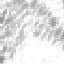

In [21]:
from torchvision.transforms.functional import to_pil_image
import torch
import PIL

to_pil_image(torch.load('/mnt/data/sonia/data/geodes-ext/train/100.100.pt')[1])

In [17]:
files = {'train': os.listdir('/mnt/data/sonia/data/geodes-ext-full/train'),
          'val': os.listdir('/mnt/data/sonia/data/geodes-ext-full/val'),
          'test': os.listdir('/mnt/data/sonia/data/geodes-ext-full/test')}

In [20]:
import os 
import shutil
import random
from tqdm import tqdm
random.seed(42)

outpath = '/mnt/data/sonia/data/geodes-ext'
for split, file_list in tqdm(files.items()):
    os.makedirs(os.path.join(outpath, split), exist_ok=True)
    num_to_select = int(len(file_list) * 0.08)
    selected_files = random.sample(file_list, num_to_select)
    for filename in tqdm(selected_files):
        shutil.copy(os.path.join(f'{outpath}-full', split, filename),
                    os.path.join(outpath, split, filename))

100%|██████████| 3/3 [08:55<00:00, 178.58s/it]
